# Dataset Exploration — AI-Original Pairwise Similarity

This notebook explores the three datasets referenced in the assessment:
1. **MIPPIA SMP** — labeled (original, similar) pairs → attribution validation
2. **SONICS** — 97k+ AI-generated tracks (Suno/Udio)
3. **FakeMusicCaps** — text-to-music clips for artifact analysis


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import librosa
import librosa.display
import warnings
warnings.filterwarnings('ignore')

SAMPLE_RATE = 22050
print('Libraries loaded OK')

Libraries loaded OK


---
## Helper: Audio analysis functions

In [11]:
def analyze_audio(path, sr=SAMPLE_RATE):
    """Extracts a summary of audio features from a file."""
    y, _ = librosa.load(path, sr=sr, mono=True)
    duration = len(y) / sr

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    spec_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    spec_flatness = librosa.feature.spectral_flatness(y=y)
    zcr = librosa.feature.zero_crossing_rate(y)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    harmonic, percussive = librosa.effects.hpss(y)
    hnr = 10 * np.log10(
        (np.mean(harmonic**2) + 1e-10) / (np.mean(percussive**2) + 1e-10)
    )
    stft = librosa.stft(y)
    phase = np.angle(stft)
    phase_disc = float(np.mean(np.abs(np.angle(np.exp(1j * np.diff(phase, axis=1))))))

    return {
        'duration_s':          round(duration, 2),
        'tempo_bpm':           round(float(np.squeeze(tempo)), 2),
        'hnr_db':              round(float(hnr), 4),
        'spectral_centroid_hz':round(float(np.mean(spec_centroid)), 2),
        'spectral_flatness':   round(float(np.mean(spec_flatness)), 6),
        'phase_discontinuity': round(phase_disc, 6),
        'zcr_mean':            round(float(np.mean(zcr)), 6),
        'mfcc1_mean':          round(float(np.mean(mfcc[0])), 4),
        'chroma_max_class':    int(np.argmax(np.mean(chroma, axis=1))),
    }


def plot_audio_overview(path, title='', sr=SAMPLE_RATE):
    """Plots waveform, mel-spectrogram, and chromagram for a track."""
    y, _ = librosa.load(path, sr=sr, mono=True, duration=60)  # first 60s for speed

    fig = plt.figure(figsize=(14, 8))
    gs = gridspec.GridSpec(3, 1, hspace=0.5)
    fig.suptitle(title or path, fontsize=13, fontweight='bold')

    # Waveform
    ax1 = fig.add_subplot(gs[0])
    librosa.display.waveshow(y, sr=sr, ax=ax1, alpha=0.7)
    ax1.set_title('Waveform')
    ax1.set_xlabel('Time (s)')

    # Mel-spectrogram
    ax2 = fig.add_subplot(gs[1])
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img = librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', ax=ax2)
    fig.colorbar(img, ax=ax2, format='%+2.0f dB')
    ax2.set_title('Mel-Spectrogram')

    # Chromagram
    ax3 = fig.add_subplot(gs[2])
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    librosa.display.specshow(chroma, sr=sr, x_axis='time', y_axis='chroma', ax=ax3)
    ax3.set_title('Chromagram (Harmonic content)')

    plt.savefig(f'exploration_{title.replace(" ", "_")}.png', dpi=120, bbox_inches='tight')
    plt.show()


print('Helper functions defined.')

Helper functions defined.


---
## Part 1: MIPPIA SMP Dataset

The most important dataset for the **attribution task**. Each row contains an (original, similar) pair.

```bash
git clone https://github.com/Mippia/smp_dataset
cd smp_dataset && python download.py
```

In [3]:
import os
from pathlib import Path

MIPPIA_CSV = Path('smp_dataset/Final_dataset_pairs.csv')
MIPPIA_AUDIO_DIR = Path('smp_dataset/final_dataset')

if not MIPPIA_CSV.exists():
    print(f'MIPPIA CSV not found: {MIPPIA_CSV.resolve()}')
elif not MIPPIA_AUDIO_DIR.exists():
    print(f'MIPPIA audio directory not found: {MIPPIA_AUDIO_DIR.resolve()}')
else:
    df = pd.read_csv(MIPPIA_CSV)
    pair_dirs = [p for p in MIPPIA_AUDIO_DIR.iterdir() if p.is_dir()]
    complete_pairs = [p for p in pair_dirs if len(list(p.glob('*.wav'))) == 2]
    incomplete_pairs = [p for p in pair_dirs if len(list(p.glob('*.wav'))) != 2]

    print(f'Total CSV rows: {len(df)}')
    print(f'Columns: {list(df.columns)}')
    print(f'Pair folders found locally: {len(pair_dirs)}')
    print(f'Complete pairs available locally: {len(complete_pairs)}')
    print(f'Incomplete pairs available locally: {len(incomplete_pairs)}')
    df.head()

Total CSV rows: 158
Columns: ['ori_title', 'comp_title', 'ori_link', 'comp_link', 'relation', 'ori_times', 'comp_times', 'pair_number']
Pair folders found locally: 70
Complete pairs available locally: 62
Incomplete pairs available locally: 8


In [4]:
# ── Distribution of similarity labels ─────────────────────────────────────────
if 'df' in dir() and 'similarity' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    df['similarity'].value_counts().plot(kind='bar', ax=axes[0], color='#3498db')
    axes[0].set_title('Similarity Label Distribution')
    axes[0].set_xlabel('Label')
    axes[0].set_ylabel('Count')

    if 'genre' in df.columns:
        df['genre'].value_counts().head(10).plot(kind='barh', ax=axes[1], color='#2ecc71')
        axes[1].set_title('Top 10 Genres')

    plt.tight_layout()
    plt.savefig('mippia_label_distribution.png', dpi=120, bbox_inches='tight')
    plt.show()

In [5]:
# ── Analyze a few MIPPIA tracks from complete local pairs ─────────────────────
if 'df' in dir() and MIPPIA_AUDIO_DIR.is_dir():
    available = []
    for pair_dir in sorted(MIPPIA_AUDIO_DIR.iterdir(), key=lambda p: int(p.name) if p.name.isdigit() else p.name):
        if not pair_dir.is_dir():
            continue
        wavs = sorted(pair_dir.glob('*.wav'))
        if len(wavs) == 2:
            available.extend(wavs)

    print(f'Downloaded audio files from complete pairs: {len(available)}')

    results = []
    for path in available[:20]:  # analyze first 20 for speed
        try:
            stats = analyze_audio(str(path))
            stats['file'] = path.name
            stats['pair_id'] = path.parent.name
            results.append(stats)
        except Exception as e:
            print(f'  Skipping {path.name}: {e}')

    mippia_df = pd.DataFrame(results)
    print(f'\nAnalyzed {len(mippia_df)} files')
    mippia_df.describe()

Downloaded audio files from complete pairs: 124

Analyzed 20 files


---
## Part 2: SONICS Dataset

> Important: in practice, **metadata exploration** can work with Hugging Face streaming, but **audio feature extraction** is more reliable after downloading the dataset locally.

Recommended local download options from the dataset page:

```python
from huggingface_hub import snapshot_download
snapshot_download(
    repo_id='awsaf49/sonics',
    repo_type='dataset',
    local_dir='data/sonics'
 )
```

or

```bash
kaggle datasets download -d awsaf49/sonics-dataset --unzip
```

This notebook therefore uses:
- streaming for a quick metadata preview
- local files for robust audio feature analysis

In [ ]:
# from huggingface_hub import snapshot_download
# snapshot_download(
#     repo_id='awsaf49/sonics',
#     repo_type='dataset',
#     local_dir='data/sonics'
#  )

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

'C:\\Users\\up105\\Documents\\Orfium_challenge\\AI_Generated_song_detection\\data\\sonics'

In [2]:
from pathlib import Path

SONICS_LOCAL_DIR = Path('data/sonics')  # change if you downloaded elsewhere

try:
    from datasets import load_dataset
    print('Loading SONICS metadata (streaming)...')
    sonics = load_dataset('awsaf49/sonics', split='train', streaming=True)
    print('SONICS loaded in streaming mode for metadata exploration.')
except Exception as e:
    print(f'Could not load SONICS in streaming mode: {e}')
    print('Run: pip install datasets')

if SONICS_LOCAL_DIR.exists():
    print(f'Local SONICS directory detected: {SONICS_LOCAL_DIR.resolve()}')
else:
    print('Local SONICS directory not found yet. Download locally if you want audio feature extraction.')

Loading SONICS metadata (streaming)...
SONICS loaded in streaming mode for metadata exploration.
Local SONICS directory detected: C:\Users\up105\Documents\Orfium_challenge\AI_Generated_song_detection\data\sonics


In [5]:
# ── Peek at first N samples from SONICS ───────────────────────────────────────
N_SAMPLES = 200

if 'sonics' in dir():
    records = []
    for i, row in enumerate(sonics):
        if i >= N_SAMPLES:
            break
        # Keep only metadata (not audio bytes) for the overview
        meta = {k: v for k, v in row.items() if k != 'audio'}
        records.append(meta)
        if (i + 1) % 50 == 0:
            print(f'  Fetched {i+1} records...')

    sonics_df = pd.DataFrame(records)
    print(f'\nColumns: {list(sonics_df.columns)}')
    print(f'Samples fetched: {len(sonics_df)}')
    sonics_df.head()

  Fetched 50 records...
  Fetched 100 records...
  Fetched 150 records...
  Fetched 200 records...

Columns: ['id', 'lyrics', 'algorithm', 'style', 'filename', 'bit_rate', 'duration', 'source', 'lyrics_feature', 'topic', 'genre', 'mood', 'label', 'filepath', 'target', 'skip_time', 'no_vocal', 'split', 'title', 'artist', 'year', 'youtube_id', 'artist_overlap']
Samples fetched: 200


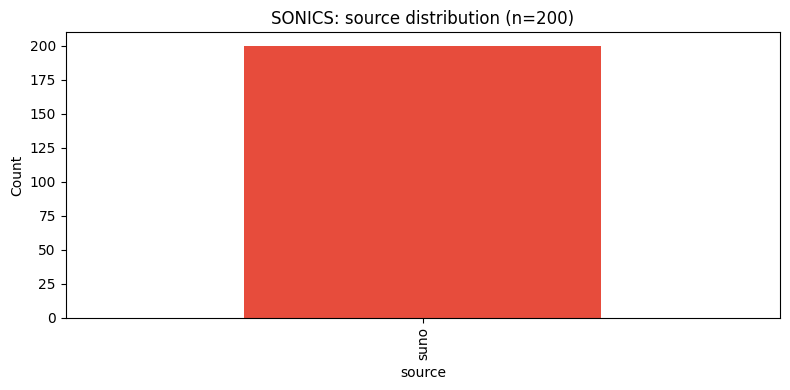


Sample metadata:
                count unique  \
id              200.0    NaN   
lyrics            200    102   
algorithm         200      1   
style             200    102   
filename          200    200   
bit_rate        200.0    NaN   
duration        200.0    NaN   
source            200      1   
lyrics_feature    200    102   
topic             200     93   
genre             200     47   
mood              200     55   
label             200      1   
filepath          200    200   
target          200.0    NaN   
skip_time       200.0    NaN   
no_vocal          200      1   
split             200      1   
title               0      0   
artist              0      0   
year                0      0   
youtube_id          0      0   
artist_overlap      0      0   

                                                              top freq  \
id                                                            NaN  NaN   
lyrics          [Intro]\n(Whoah)\nStaring at the stars, lost i...

In [6]:
# ── SONICS: generator distribution (Suno vs Udio) ────────────────────────────
if 'sonics_df' in dir():
    gen_col = [c for c in sonics_df.columns if 'source' in c.lower() or 'generator' in c.lower() or 'model' in c.lower()]
    if gen_col:
        fig, ax = plt.subplots(figsize=(8, 4))
        sonics_df[gen_col[0]].value_counts().plot(kind='bar', ax=ax, color='#e74c3c')
        ax.set_title(f'SONICS: {gen_col[0]} distribution (n={N_SAMPLES})')
        ax.set_xlabel(gen_col[0])
        ax.set_ylabel('Count')
        plt.tight_layout()
        plt.savefig('sonics_generator_dist.png', dpi=120, bbox_inches='tight')
        plt.show()

    print('\nSample metadata:')
    print(sonics_df.describe(include='all').T)

In [9]:
# ── SONICS: audio feature analysis on local files (recommended) ───────────────
import os
from pathlib import Path
import tempfile
import zipfile
import numpy as np
import pandas as pd
import librosa

if 'SAMPLE_RATE' not in globals():
    SAMPLE_RATE = 22050

if 'analyze_audio' not in globals():
    def analyze_audio(path, sr=SAMPLE_RATE):
        """Extracts a summary of audio features from a file."""
        y, _ = librosa.load(path, sr=sr, mono=True)
        duration = len(y) / sr

        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        spec_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        spec_flatness = librosa.feature.spectral_flatness(y=y)
        zcr = librosa.feature.zero_crossing_rate(y)
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
        harmonic, percussive = librosa.effects.hpss(y)
        hnr = 10 * np.log10(
            (np.mean(harmonic**2) + 1e-10) / (np.mean(percussive**2) + 1e-10)
        )
        stft = librosa.stft(y)
        phase = np.angle(stft)
        phase_disc = float(np.mean(np.abs(np.angle(np.exp(1j * np.diff(phase, axis=1))))))

        return {
            'duration_s': round(duration, 2),
            'tempo_bpm': round(float(np.squeeze(tempo)), 2),
            'hnr_db': round(float(hnr), 4),
            'spectral_centroid_hz': round(float(np.mean(spec_centroid)), 2),
            'spectral_flatness': round(float(np.mean(spec_flatness)), 6),
            'phase_discontinuity': round(phase_disc, 6),
            'zcr_mean': round(float(np.mean(zcr)), 6),
            'mfcc1_mean': round(float(np.mean(mfcc[0])), 4),
            'chroma_max_class': int(np.argmax(np.mean(chroma, axis=1))),
        }

SONICS_EXTS = {'.mp3', '.wav', '.flac', '.ogg', '.m4a'}

def find_audio_files(root: Path, limit: int = 30):
    files = []
    for path in root.rglob('*'):
        if path.is_file() and path.suffix.lower() in SONICS_EXTS:
            files.append(path)
            if len(files) >= limit:
                break
    return files

def analyze_audio_members_from_archives(zip_files, limit: int = 30):
    features = []
    errors = []
    processed = 0

    for zip_path in zip_files:
        if processed >= limit:
            break

        try:
            with zipfile.ZipFile(zip_path) as zf:
                audio_members = [
                    name for name in zf.namelist()
                    if Path(name).suffix.lower() in SONICS_EXTS and not name.endswith('/')
                ]

                for member in audio_members:
                    if processed >= limit:
                        break

                    tmp_path = None
                    try:
                        suffix = Path(member).suffix or '.wav'
                        with zf.open(member) as src, tempfile.NamedTemporaryFile(suffix=suffix, delete=False) as tmp:
                            tmp.write(src.read())
                            tmp_path = tmp.name

                        stats = analyze_audio(tmp_path)
                        stats['source'] = 'local_sonics_zip'
                        stats['file'] = Path(member).name
                        stats['archive'] = zip_path.name
                        features.append(stats)
                        processed += 1

                        if processed % 10 == 0:
                            print(f'  Processed {processed}/{limit} archived local files...')

                    except Exception as e:
                        errors.append({'sample_index': processed, 'file': member, 'archive': zip_path.name, 'error': str(e)})
                        print(f'  Error at archived file {member}: {e}')

                    finally:
                        if tmp_path and os.path.exists(tmp_path):
                            os.unlink(tmp_path)

        except Exception as e:
            errors.append({'archive': zip_path.name, 'error': str(e)})
            print(f'  Could not open archive {zip_path.name}: {e}')

    return features, errors

sonics_features = []
sonics_errors = []

if SONICS_LOCAL_DIR.exists():
    local_audio_files = find_audio_files(SONICS_LOCAL_DIR, limit=30)

    if local_audio_files:
        print(f'Found {len(local_audio_files)} local SONICS audio files for analysis.')

        for i, path in enumerate(local_audio_files):
            try:
                stats = analyze_audio(str(path))
                stats['source'] = 'local_sonics'
                stats['file'] = path.name
                sonics_features.append(stats)
            except Exception as e:
                sonics_errors.append({'sample_index': i, 'file': path.name, 'error': str(e)})
                print(f'  Error at file {path.name}: {e}')

            if (i + 1) % 10 == 0:
                print(f'  Processed {i+1}/{len(local_audio_files)} local files...')

    else:
        zip_dir = SONICS_LOCAL_DIR / 'fake_songs'
        zip_files = sorted(zip_dir.glob('*.zip')) if zip_dir.exists() else []

        if zip_files:
            print(f'Found {len(zip_files)} SONICS zip archives. Sampling audio directly from archives...')
            sonics_features, sonics_errors = analyze_audio_members_from_archives(zip_files, limit=30)
        else:
            print('SONICS local directory exists, but no loose audio files or zip archives were found.')

elif 'sonics' in dir():
    print('No local SONICS folder found. Trying streaming audio payloads as a fallback...')
    try:
        sonics_iter = load_dataset('awsaf49/sonics', split='train', streaming=True)
    except Exception as e:
        sonics_iter = None
        print(f'Could not re-open SONICS stream: {e}')

    if sonics_iter is not None:
        import soundfile as sf

        for i, row in enumerate(sonics_iter):
            if i >= 30:
                break

            tmp_path = None
            try:
                audio_data = row.get('audio')
                if not isinstance(audio_data, dict):
                    sonics_errors.append({'sample_index': i, 'error': f'Unexpected audio payload type: {type(audio_data).__name__}'})
                    continue

                if 'array' not in audio_data or 'sampling_rate' not in audio_data:
                    sonics_errors.append({'sample_index': i, 'error': f'Audio payload keys: {list(audio_data.keys())}'})
                    continue

                y = np.asarray(audio_data['array'], dtype=np.float32)
                sr = int(audio_data['sampling_rate'])

                if y.size == 0:
                    sonics_errors.append({'sample_index': i, 'error': 'Empty audio array'})
                    continue

                with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as tmp:
                    tmp_path = tmp.name

                sf.write(tmp_path, y, sr)
                stats = analyze_audio(tmp_path, sr=sr)
                stats['source'] = row.get('source', row.get('generator', row.get('model', 'unknown')))
                sonics_features.append(stats)

            except Exception as e:
                sonics_errors.append({'sample_index': i, 'error': str(e)})
                print(f'  Error at sample {i}: {e}')

            finally:
                if tmp_path and os.path.exists(tmp_path):
                    os.unlink(tmp_path)

            if (i + 1) % 10 == 0:
                print(f'  Processed {i+1}/30 streaming samples...')
else:
    print('SONICS is not available yet. Load the dataset or download it locally first.')

sonics_feat_df = pd.DataFrame(sonics_features)
print(f'\nFeature stats for {len(sonics_feat_df)} SONICS tracks')
print(f'Errors: {len(sonics_errors)}')

if sonics_errors:
    sonics_error_df = pd.DataFrame(sonics_errors)
    print('\nFirst SONICS errors:')
    display(sonics_error_df.head())

if sonics_feat_df.empty:
    print('No SONICS features were extracted.')
    print('Recommended fix: verify the local SONICS snapshot layout or use streaming for a smaller sample.')
else:
    display(sonics_feat_df.describe(include='all').T)

Found 10 SONICS zip archives. Sampling audio directly from archives...
  Processed 10/30 archived local files...
  Processed 20/30 archived local files...
  Processed 30/30 archived local files...

Feature stats for 30 SONICS tracks
Errors: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
duration_s,30.0,NaN,NaN,NaN,174.906667,44.851469,117.0,131.11,167.46,221.06,240.0
tempo_bpm,30.0,NaN,NaN,NaN,117.300667,25.766313,73.83,103.36,112.35,138.425,172.27
hnr_db,30.0,NaN,NaN,NaN,5.55073,3.036457,-0.9107,3.59245,5.32665,7.9139,11.9033
spectral_centroid_hz,30.0,NaN,NaN,NaN,1812.187333,313.154463,1225.21,1614.54,1867.82,2036.2475,2365.24
spectral_flatness,30.0,NaN,NaN,NaN,0.000939,0.001659,0.000015,0.000044,0.000086,0.001284,0.005582
phase_discontinuity,30.0,NaN,NaN,NaN,1.568317,0.004604,1.556128,1.566032,1.568748,1.571708,1.574356
zcr_mean,30.0,NaN,NaN,NaN,0.086859,0.02268,0.041916,0.069607,0.088095,0.102139,0.131681
mfcc1_mean,30.0,NaN,NaN,NaN,-166.193613,51.404134,-235.2242,-207.627175,-177.19575,-111.938125,-66.1065
chroma_max_class,30.0,NaN,NaN,NaN,5.266667,3.073057,0.0,3.0,5.5,8.0,11.0
source,30,1,local_sonics_zip,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## Part 3: FakeMusicCaps Dataset

The Hugging Face path used earlier is not the correct public source for this dataset.
Use the Zenodo release instead:
- Record: https://zenodo.org/records/15063698
- File: `FakeMusicCaps.zip` (~12.9 GB)

The dataset appears to contain 10-second `.wav` clips organized by TTM model folders.
This section therefore assumes one of these local layouts:
- `data/FakeMusicCaps.zip`
- `data/FakeMusicCaps/` (already extracted)

In [ ]:
from pathlib import Path
import zipfile

FMC_ZIP_PATH = Path('data/FakeMusicCaps.zip')
FMC_EXTRACT_DIR = Path('data/FakeMusicCaps')
FMC_AUDIO_EXTS = {'.wav', '.mp3', '.flac', '.ogg', '.m4a'}

if FMC_EXTRACT_DIR.exists():
    print(f'Local FakeMusicCaps directory detected: {FMC_EXTRACT_DIR.resolve()}')
elif FMC_ZIP_PATH.exists():
    print(f'Local FakeMusicCaps zip detected: {FMC_ZIP_PATH.resolve()}')
else:
    print('FakeMusicCaps not found locally.')
    

FakeMusicCaps not found locally.
Download FakeMusicCaps.zip from https://zenodo.org/records/15063698 and place it under data/


In [ ]:
# ── FakeMusicCaps: metadata overview from local zip or extracted folder ───────
def build_fmc_records(limit: int = 100):
    records = []

    if FMC_EXTRACT_DIR.exists():
        for path in FMC_EXTRACT_DIR.rglob('*'):
            if path.is_file() and path.suffix.lower() in FMC_AUDIO_EXTS:
                model_name = path.parent.name
                records.append({
                    'file': path.name,
                    'model': model_name,
                    'source': 'local_extracted',
                })
                if len(records) >= limit:
                    break

    elif FMC_ZIP_PATH.exists():
        with zipfile.ZipFile(FMC_ZIP_PATH) as zf:
            for member in zf.namelist():
                member_path = Path(member)
                if member.endswith('/') or member_path.suffix.lower() not in FMC_AUDIO_EXTS:
                    continue
                if member_path.name.startswith('._'):
                    continue
                parts = member_path.parts
                model_name = parts[0] if len(parts) > 1 else 'unknown'
                records.append({
                    'file': member_path.name,
                    'model': model_name,
                    'source': 'local_zip',
                })
                if len(records) >= limit:
                    break

    return records

fmc_records = build_fmc_records(limit=100)

if fmc_records:
    fmc_df = pd.DataFrame(fmc_records)
    print(f'Columns: {list(fmc_df.columns)}')
    print(f'Samples indexed: {len(fmc_df)}')
    fmc_df.head()
else:
    print('No FakeMusicCaps records found locally.')

In [ ]:
# ── FakeMusicCaps: model distribution ────────────────────────────────────────
if 'fmc_df' in dir() and not fmc_df.empty:
    fig, ax = plt.subplots(figsize=(9, 4))
    fmc_df['model'].value_counts().plot(kind='bar', ax=ax, color='#9b59b6')
    ax.set_title(f'FakeMusicCaps: TTM model distribution (n={len(fmc_df)})')
    ax.set_xlabel('Model')
    ax.set_ylabel('Count')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig('fmc_model_dist.png', dpi=120, bbox_inches='tight')
    plt.show()

---
## Part 4: Cross-dataset feature comparison

Compare HNR, spectral flatness, and phase discontinuity between **human** (MIPPIA) and **AI** (SONICS/FakeMusicCaps) tracks.
This validates whether AI artifacts are distinguishable in our feature space.

In [ ]:
# Build a combined dataframe with 'source' label = 'human' or 'ai'
frames = []

if 'mippia_df' in dir():
    tmp = mippia_df.copy()
    tmp['source'] = 'human'
    frames.append(tmp)

if 'sonics_feat_df' in dir():
    tmp = sonics_feat_df.copy()
    tmp['source'] = 'ai'
    frames.append(tmp)

if frames:
    combined = pd.concat(frames, ignore_index=True)
    print(f'Combined: {combined["source"].value_counts().to_dict()}')
    combined.groupby('source')[['hnr_db','spectral_flatness','phase_discontinuity','tempo_bpm']].mean()

In [ ]:
# ── Violin plots: Human vs AI feature distributions ───────────────────────────
if 'combined' in dir():
    features_to_plot = ['hnr_db', 'spectral_flatness', 'phase_discontinuity', 'tempo_bpm']
    fig, axes = plt.subplots(1, len(features_to_plot), figsize=(16, 5))

    colors = {'human': '#2ecc71', 'ai': '#e74c3c'}

    for ax, feat in zip(axes, features_to_plot):
        for label, grp in combined.groupby('source'):
            vals = grp[feat].dropna()
            parts = ax.violinplot([vals], positions=[list(colors.keys()).index(label)],
                                  showmedians=True)
            for pc in parts['bodies']:
                pc.set_facecolor(colors[label])
                pc.set_alpha(0.7)

        ax.set_title(feat.replace('_', ' ').title())
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Human', 'AI'])

    plt.suptitle('Human vs AI: Feature Distributions', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('human_vs_ai_features.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: human_vs_ai_features.png')

---
## Part 5: Single track deep-dive

Visualize waveform, mel-spectrogram and chromagram for any audio file.

In [ ]:
# Change these paths to any audio files you have
TRACK_ORIGINAL = 'original.mp3'   # human original
TRACK_AI       = 'ai_cover.mp3'   # suspected AI cover

for path, label in [(TRACK_ORIGINAL, 'Original (Human)'), (TRACK_AI, 'Suspected AI Cover')]:
    if os.path.exists(path):
        print(f'\n--- {label} ---')
        stats = analyze_audio(path)
        for k, v in stats.items():
            print(f'  {k:28s}: {v}')
        plot_audio_overview(path, title=label)
    else:
        print(f'File not found: {path} (skipping)')

---
## Key Insights Summary

After running the above cells, note the following patterns:

| Observation | What it means for the system |
|---|---|
| AI tracks tend to have more extreme **spectral flatness** values | Use as AI artifact feature |
| AI tracks show higher **phase discontinuity** in STFT | Use as AI artifact feature |
| **Chroma** profiles are similar for attribution pairs | Good signal for melody matching |
| **Tempo** is often preserved in AI covers | Include in similarity score |
| **HNR** differs between human and AI vocals | Useful for vocal-heavy tracks |